$T_0$ berechnen

In [34]:
import numpy as np
import uncertainties as unc
import uncertainties.unumpy as unp
import matplotlib.pyplot as plt


In [31]:
T = np.array([39.61, 39.72, 39.73])

unc_T = 0.25

T = unp.uarray(T, unc_T)
T_0 = T/20
T_0
T_fin_err = np.sqrt((np.std(unp.nominal_values(T_0), ddof=1) / np.sqrt(len(T_0)))**2 + 0.013**2)
T_fin = unc.ufloat(
    float(np.mean(unp.nominal_values(T_0))),
    float(T_fin_err)
)
T_fin



1.984333333333333+/-0.013141325825214307

In [ ]:

i1_run1 = [20.0, 16.5, 13.6, 11.2, 9.2, 7.6, 6.2, 5.0, 4.0, 3.2, 2.6, 2.1, 1.7, 1.3, 1.0, 0.8, 0.6, 0.5]
i1_run2 = [20.0, 16.2, 13.5, 11.1, 9.0, 7.4, 6.0, 5.0, 4.0, 3.2, 2.6, 2.0, 1.6, 1.3, 1.0, 0.8, 0.6, 0.4]

i2_run1 = [20.0, 14.6, 10.7, 7.8, 5.6, 4.1, 2.9, 2.0, 1.4, 1.0, 0.7, 0.5, 0.3]
i2_run2 = [20.0, 14.8, 10.7, 7.8, 5.6, 4.1, 2.9, 2.0, 1.4, 1.0, 0.6, 0.2]

def calculate_averages(run1, run2, n_max):
    averages = []
    for i in range(n_max):
        values = []
        if i < len(run1): values.append(run1[i])
        if i < len(run2): values.append(run2[i])
        
        if values:
            avg = sum(values) / len(values)
            averages.append(avg)
        else:
            averages.append(None)
    return averages



# Process averages
i1_avg = calculate_averages(i1_run1, i1_run2, len(i1_run1))
i2_avg = calculate_averages(i2_run1, i2_run2,  len(i2_run1))

#print("Averages for Damping Current 1:", i1_avg)
#print("Averages for Damping Current 2:", i2_avg)
#

Averages for Damping Current 1: [20.0, 16.35, 13.55, 11.149999999999999, 9.1, 7.5, 6.1, 5.0, 4.0, 3.2, 2.6, 2.05, 1.65, 1.3, 1.0, 0.8, 0.6, 0.45]
Averages for Damping Current 2: [20.0, 14.7, 10.7, 7.8, 5.6, 4.1, 2.9, 2.0, 1.4, 1.0, 0.6499999999999999, 0.35, 0.3]


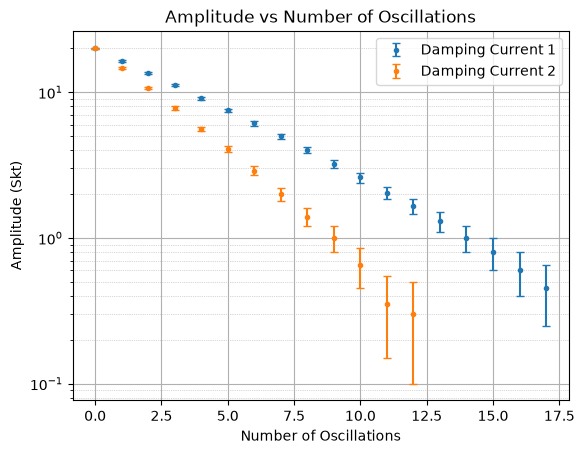

In [51]:
plt.errorbar(range(len(i1_avg)), i1_avg, yerr=0.2, fmt='.', label='Damping Current 1', capsize=3)
plt.errorbar(range(len(i2_avg)), i2_avg, yerr=0.2, fmt='.', label='Damping Current 2', capsize=3)
plt.xlabel('Number of Oscillations')
plt.ylabel('Amplitude (Skt)')
plt.title('Amplitude vs Number of Oscillations')
plt.legend()
plt.yscale('log')
plt.grid()
plt.grid(which='minor', linestyle=':', linewidth=0.5)
